# Week 1 — Sanity Check: Chicago Pedestrian Network

**Purpose:** Verify that the OSMnx download ran correctly, the graph is projected,
and the street network looks geographically sensible before we build features on top of it.

**Run order:** Execute `src/ingestion/fetch_osm_network.py` first, then run all cells here.

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import osmnx as ox
import contextily as ctx

# Make src/ importable from notebook
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_OSM_DIR = PROJECT_ROOT / 'data' / 'raw' / 'osm'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root  : {PROJECT_ROOT}')
print(f'OSM data dir  : {RAW_OSM_DIR}')
print(f'OSMnx version : {ox.__version__}')
print(f'GeoPandas ver : {gpd.__version__}')

Project root  : /Users/linhle/Fun/walkability-engine
OSM data dir  : /Users/linhle/Fun/walkability-engine/data/raw/osm
OSMnx version : 2.1.0
GeoPandas ver : 1.1.3


## 1. Load the saved graph and GeoDataFrames

In [2]:
# ── Load GraphML ──────────────────────────────────────────────────────────────
graphml_path = RAW_OSM_DIR / 'chicago_walk_graph.graphml'

assert graphml_path.exists(), (
    f'GraphML not found at {graphml_path}\n'
    'Run: python -m src.ingestion.fetch_osm_network  before this notebook.'
)

print('Loading GraphML (may take ~30s for Chicago) …')
G = ox.load_graphml(filepath=str(graphml_path))
print(f'Graph loaded   : {len(G.nodes):,} nodes  |  {len(G.edges):,} edges')

Loading GraphML (may take ~30s for Chicago) …
Graph loaded   : 308,833 nodes  |  1,038,504 edges


In [3]:
# ── Load GeoDataFrames from GeoPackage ────────────────────────────────────────
edges = gpd.read_file(RAW_OSM_DIR / 'chicago_walk_edges.gpkg', layer='edges')
nodes = gpd.read_file(RAW_OSM_DIR / 'chicago_walk_nodes.gpkg', layer='nodes')

print(f'Edges GDF : {len(edges):,} rows  |  CRS: {edges.crs}')
print(f'Nodes GDF : {len(nodes):,} rows  |  CRS: {nodes.crs}')
print()
print('Edge columns:')
print(list(edges.columns))

Edges GDF : 1,038,504 rows  |  CRS: EPSG:26916
Nodes GDF : 308,833 rows  |  CRS: EPSG:26916

Edge columns:
['u', 'v', 'key', 'osmid', 'highway', 'oneway', 'reversed', 'length', 'name', 'lanes', 'maxspeed', 'ref', 'bridge', 'width', 'service', 'access', 'tunnel', 'junction', 'geometry']


## 2. CRS Validation

The graph should be projected to **EPSG:26916** (UTM Zone 16N, Chicago).
All distance-based features in later weeks depend on this being in metres.

In [4]:
# ── CRS checks ────────────────────────────────────────────────────────────────
expected_crs = 'EPSG:26916'

assert edges.crs.to_epsg() == 26916, (
    f'Edges CRS is {edges.crs} — expected {expected_crs}. '
    'Re-run ingestion with --crs EPSG:26916'
)
assert nodes.crs.to_epsg() == 26916, (
    f'Nodes CRS is {nodes.crs} — expected {expected_crs}.'
)

print(f'CRS check PASSED  :  {edges.crs}')

# Units should be metres — verify bounding box is ~city-scale
total_bounds = edges.total_bounds   # (minx, miny, maxx, maxy) in metres
width_km  = (total_bounds[2] - total_bounds[0]) / 1000
height_km = (total_bounds[3] - total_bounds[1]) / 1000
print(f'Bounding box      :  {width_km:.1f} km (W–E)  x  {height_km:.1f} km (N–S)')

# Chicago is roughly 42 km N–S and 25 km E–W — warn if very different
if not (15 < width_km < 50 and 30 < height_km < 70):
    print('WARNING: bounding box looks unusual — double-check the query covers the full city.')
else:
    print('Bounding box looks sensible for Chicago.')

CRS check PASSED  :  EPSG:26916
Bounding box      :  28.3 km (W–E)  x  42.7 km (N–S)
Bounding box looks sensible for Chicago.


## 3. Basic Statistics

In [5]:
# ── OSMnx basic stats ─────────────────────────────────────────────────────────
# Note: basic_stats expects a projected graph; G is already projected.
stats = ox.stats.basic_stats(G)

print('─' * 50)
print('NETWORK STATISTICS')
print('─' * 50)
key_stats = [
    ('n_nodes',              'Nodes (intersections + dead-ends)'),
    ('n_edges',              'Edges (street segments)'),
    ('edge_length_total',    'Total street length (m)'),
    ('edge_length_avg',      'Mean edge length (m)'),
    ('street_length_avg',    'Mean street length (m)'),
    ('intersection_count',   'Intersections'),
    ('street_density_km',    'Street density (km/km²)'),
    ('node_density_km',      'Node density (nodes/km²)'),
    ('intersection_density_km', 'Intersection density (/km²)'),
]
for key, label in key_stats:
    val = stats.get(key, 'N/A')
    if isinstance(val, float):
        print(f'  {label:<42} {val:>12,.1f}')
    else:
        print(f'  {label:<42} {str(val):>12}')
print('─' * 50)

──────────────────────────────────────────────────
NETWORK STATISTICS
──────────────────────────────────────────────────
  Nodes (intersections + dead-ends)                   N/A
  Edges (street segments)                             N/A
  Total street length (m)                    44,529,747.8
  Mean edge length (m)                               42.9
  Mean street length (m)                             42.9
  Intersections                                    277542
  Street density (km/km²)                             N/A
  Node density (nodes/km²)                            N/A
  Intersection density (/km²)                         N/A
──────────────────────────────────────────────────


## 4. Edge Length Distribution

We expect a roughly log-normal distribution centred around 80–150m for a US city grid.
Very long edges (>1 km) usually indicate highways or bridges that slipped through the pedestrian filter — inspect them.

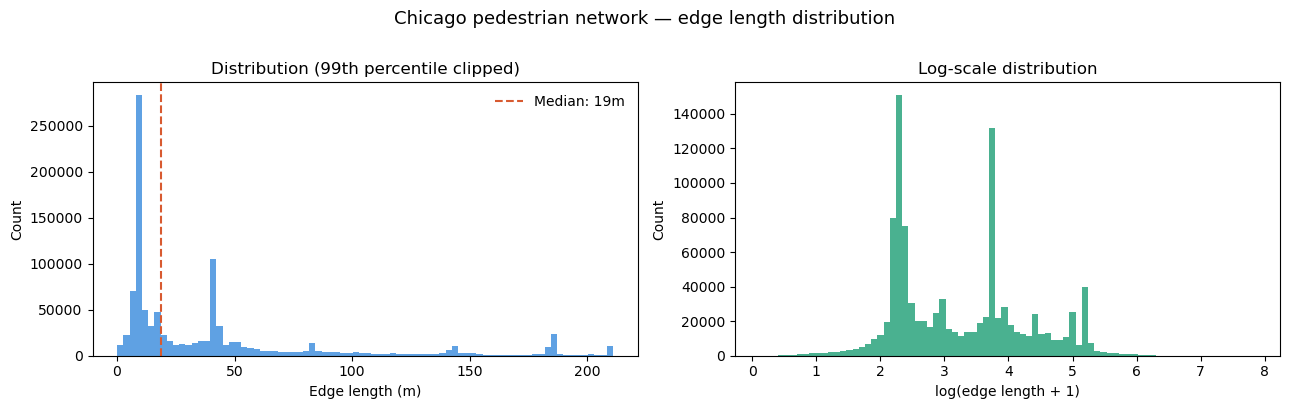


Edge length summary:
count    1038504.0
mean          42.9
std           55.4
min            0.1
25%            9.1
50%           18.9
75%           45.9
max         2572.4


In [6]:
# ── Edge length distribution ──────────────────────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Chicago pedestrian network — edge length distribution', fontsize=13, y=1.01)

lengths = edges['length'].dropna()

# Raw distribution
axes[0].hist(lengths.clip(upper=lengths.quantile(0.99)), bins=80, color='#378ADD', alpha=0.8, edgecolor='none')
axes[0].axvline(lengths.median(), color='#D85A30', linewidth=1.5, linestyle='--', label=f'Median: {lengths.median():.0f}m')
axes[0].set_xlabel('Edge length (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution (99th percentile clipped)')
axes[0].legend(frameon=False)

# Log scale
axes[1].hist(np.log1p(lengths), bins=80, color='#1D9E75', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('log(edge length + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-scale distribution')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w01_edge_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nEdge length summary:\n{lengths.describe().round(1).to_string()}')

## 5. Full Network Visualisation

Render the pedestrian network with a basemap. The network should cover all of Chicago's 77 community areas.
Visually check: does it reach the far South Side? The Northeaster lakeshore? O'Hare area (far NW)?

Network map saved → outputs/figures/w01_chicago_pedestrian_network.png


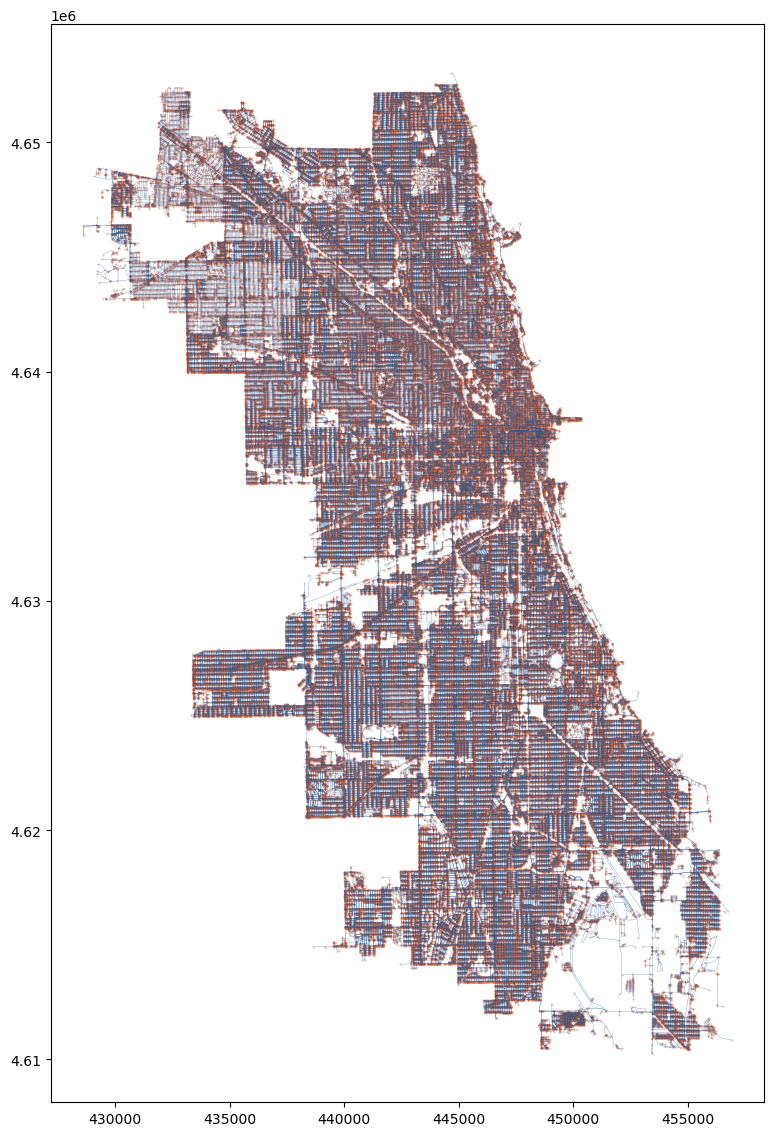

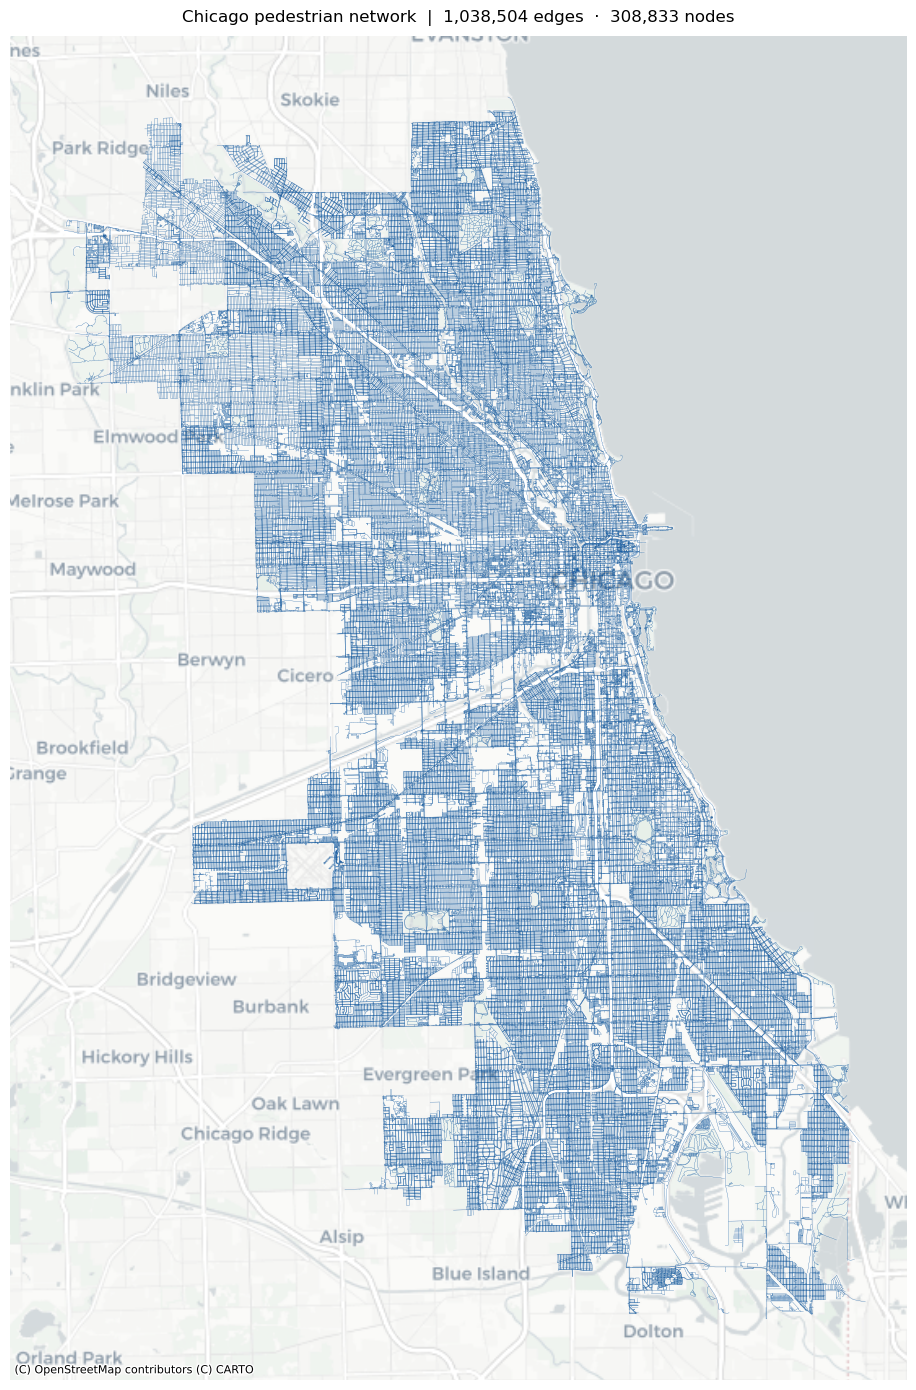

In [7]:
# ── Full-city network map ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 14))

edges.plot(
    ax=ax,
    linewidth=0.15,
    color='#185FA5',
    alpha=0.6,
)
nodes.plot(
    ax=ax,
    markersize=0.4,
    color='#D85A30',
    alpha=0.3,
)

# Reproject to Web Mercator for contextily basemap
edges_wm = edges.to_crs(epsg=3857)
ax_wm = edges_wm.plot(linewidth=0.15, color='#185FA5', alpha=0.7, figsize=(10, 14))
try:
    ctx.add_basemap(ax_wm, source=ctx.providers.CartoDB.Positron, zoom=11)
except Exception:
    pass  # basemap is cosmetic — don't fail if tiles are unavailable

ax_wm.set_axis_off()
ax_wm.set_title(
    f'Chicago pedestrian network  |  {len(edges):,} edges  ·  {len(nodes):,} nodes',
    fontsize=12, pad=10
)

plt.tight_layout()
fig_path = FIGURES_DIR / 'w01_chicago_pedestrian_network.png'
ax_wm.figure.savefig(fig_path, dpi=180, bbox_inches='tight')
print(f'Network map saved → {fig_path.relative_to(PROJECT_ROOT)}')
plt.show()

## 6. Street Type Breakdown

Confirms the pedestrian filter worked. We should see mostly `residential`, `footway`,
`path`, `service`, and `unclassified` — very few `motorway` or `trunk` edges.

Consider adding custom_filter to OSMnx query in fetch_osm_network.py


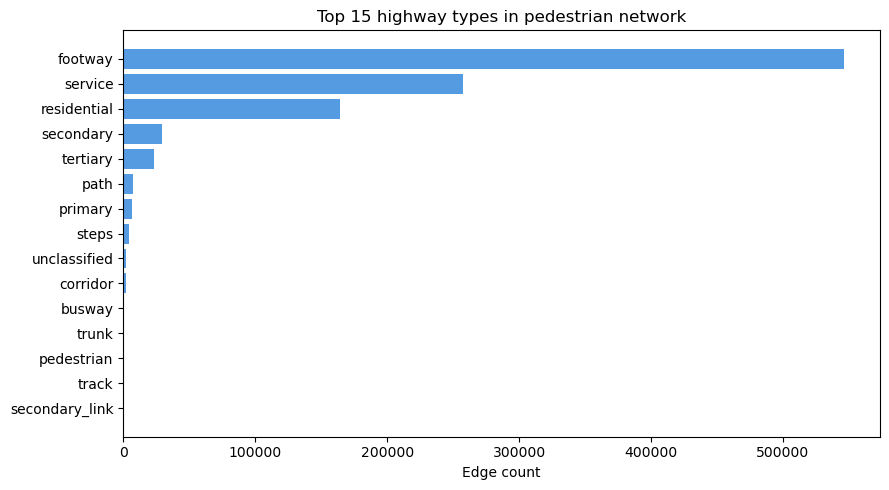

highway
footway           546232
service           257442
residential       164054
secondary          29036
tertiary           23162
path                7010
primary             6436
steps               4084
unclassified        1886
corridor            1764
busway               824
trunk                762
pedestrian           700
track                382
secondary_link       340


In [8]:
# ── Highway type distribution ─────────────────────────────────────────────────
if 'highway' in edges.columns:
    highway_counts = (
        edges['highway']
        .str.split('|').explode()  # handle multi-value '|'-separated strings
        .value_counts()
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(
        highway_counts.index[::-1],
        highway_counts.values[::-1],
        color='#378ADD', alpha=0.85, edgecolor='none'
    )
    ax.set_xlabel('Edge count')
    ax.set_title('Top 15 highway types in pedestrian network', fontsize=12)

    # Flag any highway types that shouldn't be here
    bad_types = {'motorway', 'motorway_link', 'trunk'}
    bad_present = bad_types.intersection(set(highway_counts.index))
    if bad_present:
        print(f'WARNING: These highway types should not appear in walk network: {bad_present}')
        print('Consider adding custom_filter to OSMnx query in fetch_osm_network.py')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'w01_highway_types.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(highway_counts.to_string())
else:
    print('No highway column found in edges GDF.')

## 7. Spot-Check: Known Walkable vs. Car-Dependent Neighbourhoods

Crop the network to two areas we know differ in walkability:
- **The Loop / Near North Side** → dense grid, should show many short edges
- **Hegewisch / far SE Chicago** → sparse industrial/residential, fewer edges

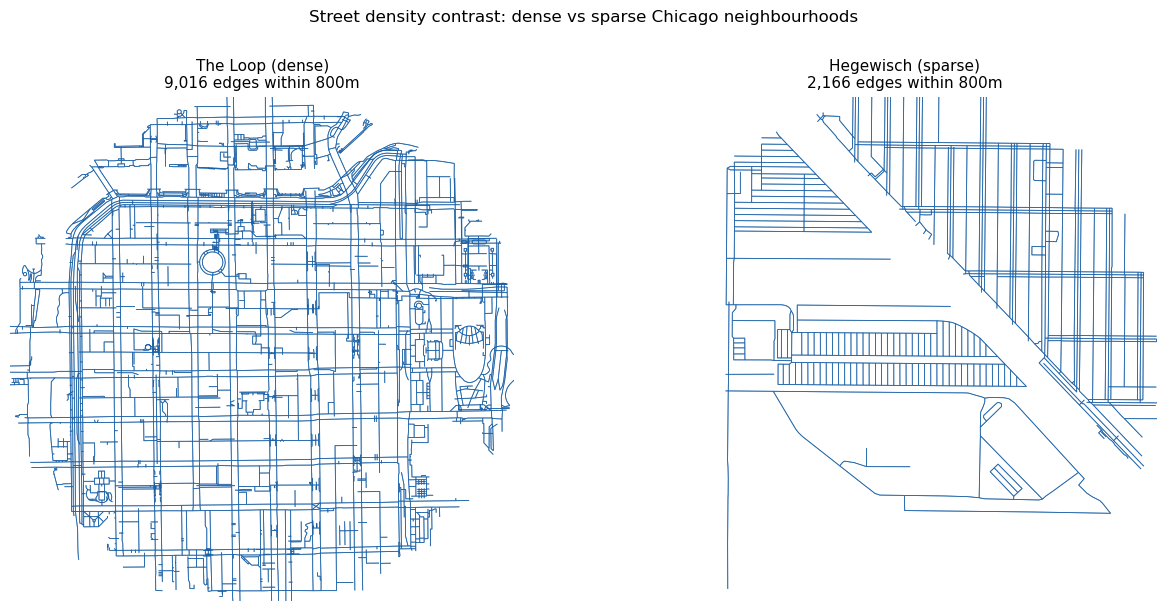

If The Loop clearly has more edges per area than Hegewisch, the network data is correct.


In [9]:
# ── Spot-check two contrasting neighbourhoods ─────────────────────────────────
from shapely.geometry import Point

SPOTS = {
    'The Loop (dense)':         (-87.6298, 41.8827),   # lon, lat
    'Hegewisch (sparse)':       (-87.5525, 41.6497),
}
BUFFER_M = 800   # 800m radius crop

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (name, (lon, lat)) in zip(axes, SPOTS.items()):
    # Project centroid to UTM
    centre = gpd.GeoDataFrame(
        geometry=[Point(lon, lat)], crs='EPSG:4326'
    ).to_crs('EPSG:26916').geometry.iloc[0]

    crop = edges[edges.geometry.centroid.distance(centre) < BUFFER_M]

    crop.plot(ax=ax, linewidth=0.6, color='#185FA5', alpha=0.8)
    ax.set_xlim(centre.x - BUFFER_M, centre.x + BUFFER_M)
    ax.set_ylim(centre.y - BUFFER_M, centre.y + BUFFER_M)
    ax.set_title(f'{name}\n{len(crop):,} edges within {BUFFER_M}m', fontsize=11)
    ax.set_aspect('equal')
    ax.set_axis_off()

fig.suptitle('Street density contrast: dense vs sparse Chicago neighbourhoods', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w01_neighbourhood_contrast.png', dpi=150, bbox_inches='tight')
plt.show()
print('If The Loop clearly has more edges per area than Hegewisch, the network data is correct.')

## 8. Final Checklist

Run this cell last. All assertions must pass before committing Week 1.

In [10]:
# ── Final checklist ───────────────────────────────────────────────────────────
checks = []

def check(label, condition, fix=''):
    status = 'PASS' if condition else 'FAIL'
    checks.append((status, label, fix))

check('GraphML file exists',       graphml_path.exists())
check('Edges GPKG exists',         (RAW_OSM_DIR / 'chicago_walk_edges.gpkg').exists())
check('Nodes GPKG exists',         (RAW_OSM_DIR / 'chicago_walk_nodes.gpkg').exists())
check('Node count >= 80,000',      len(G.nodes) >= 80_000,        fix='Network may be incomplete — re-run ingestion')
check('Edge count >= 150,000',     len(G.edges) >= 150_000,       fix='Network may be incomplete — re-run ingestion')
check('CRS is EPSG:26916',         edges.crs.to_epsg() == 26916,  fix='Re-run ingestion with --crs EPSG:26916')
check('No NaN geometries in edges',edges.geometry.isna().sum() == 0)
check('Figures directory has PNGs',len(list(FIGURES_DIR.glob('w01_*.png'))) >= 3)

print('\nWEEK 1 FINAL CHECKLIST')
print('─' * 55)
all_pass = True
for status, label, fix in checks:
    icon = '✓' if status == 'PASS' else '✗'
    print(f'  {icon}  {label}')
    if status == 'FAIL':
        all_pass = False
        if fix:
            print(f'       → {fix}')
print('─' * 55)
if all_pass:
    print('  All checks passed.  Ready to commit Week 1 and begin Week 2.')
else:
    print('  Some checks failed. Fix issues above before proceeding.')


WEEK 1 FINAL CHECKLIST
───────────────────────────────────────────────────────
  ✓  GraphML file exists
  ✓  Edges GPKG exists
  ✓  Nodes GPKG exists
  ✓  Node count >= 80,000
  ✓  Edge count >= 150,000
  ✓  CRS is EPSG:26916
  ✓  No NaN geometries in edges
  ✓  Figures directory has PNGs
───────────────────────────────────────────────────────
  All checks passed.  Ready to commit Week 1 and begin Week 2.
